In [29]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import hmean

sns.set_style("whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

data_list = []
for filename in os.listdir("results_geg_rq5"):
    if filename.endswith(".csv"):
        dataset = filename.split("_")[0]
        df = pd.read_csv(os.path.join("results_geg_rq5", filename))
        df["dataset"] = dataset
        data_list.append(df)
data = pd.concat(data_list, ignore_index=True)

In [30]:
data = data.drop(columns=['statistical_parity', 'equal_opportunity', 'average_odds'])

In [31]:
data[["wc_statistical_parity", "wc_equal_opportunity", "wc_average_odds"]] = data[
    ["wc_statistical_parity", "wc_equal_opportunity", "wc_average_odds"]
].abs()

In [32]:
data['harmonic_mean'] = data.apply(
    lambda row: hmean([row['accuracy'], row['f1_score'], 1 - row['wc_statistical_parity'], 1 - row['wc_equal_opportunity'], 1 - row['wc_average_odds']]),
    axis=1)

In [33]:
data

,fold,accuracy,precision,recall,f1_score,wc_statistical_parity,wc_equal_opportunity,wc_average_odds,constraint,difference_bound,dataset,harmonic_mean
0,1,0.6014,0.5699,0.5506,0.5343,0.0424,0.2500,0.0848,dp,0.0000,cmc,0.7138
1,2,0.6149,0.6062,0.5678,0.5494,0.0468,0.1508,0.0518,dp,0.0000,cmc,0.7432
2,3,0.5608,0.5108,0.5106,0.5050,0.0420,0.1180,0.0787,dp,0.0000,cmc,0.7116
3,4,0.5782,0.6357,0.5436,0.5191,0.0264,0.1088,0.1079,dp,0.0000,cmc,0.7219
4,5,0.6259,0.5895,0.5522,0.5558,0.0258,0.2353,0.1434,dp,0.0000,cmc,0.7248
...,...,...,...,...,...,...,...,...,...,...,...,...
4195,6,0.6543,0.6226,0.6029,0.6044,0.1345,0.2789,0.1679,eo,0.0950,drug,0.7218
4196,7,0.6968,0.5701,0.6055,0.5693,0.3072,0.4500,0.2864,eo,0.0950,drug,0.6366
4197,8,0.6915,0.6202,0.6024,0.6069,0.1773,0.4000,0.2317,eo,0.0950,drug,0.6870
4198,9,0.6436,0.5865,0.5986,0.5880,0.0334,0.1531,0.0530,eo,0.0950,drug,0.7662


In [34]:
data['constraint'] = data['constraint'].replace({
    'dp': 'GEG-SP',
    'eo': 'GEG-EO',
    'cp': 'GEG-CP',
})

<Axes: xlabel='difference_bound'>

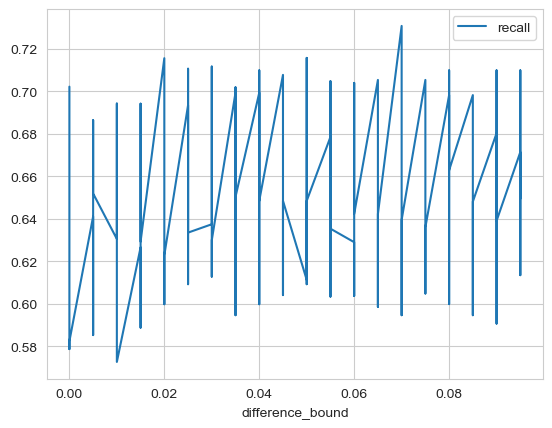

In [35]:
data[(data["dataset"] == "obesity") & (data["constraint"] == "GEG-EO")].plot(
    y="recall", x="difference_bound", kind="line"
)

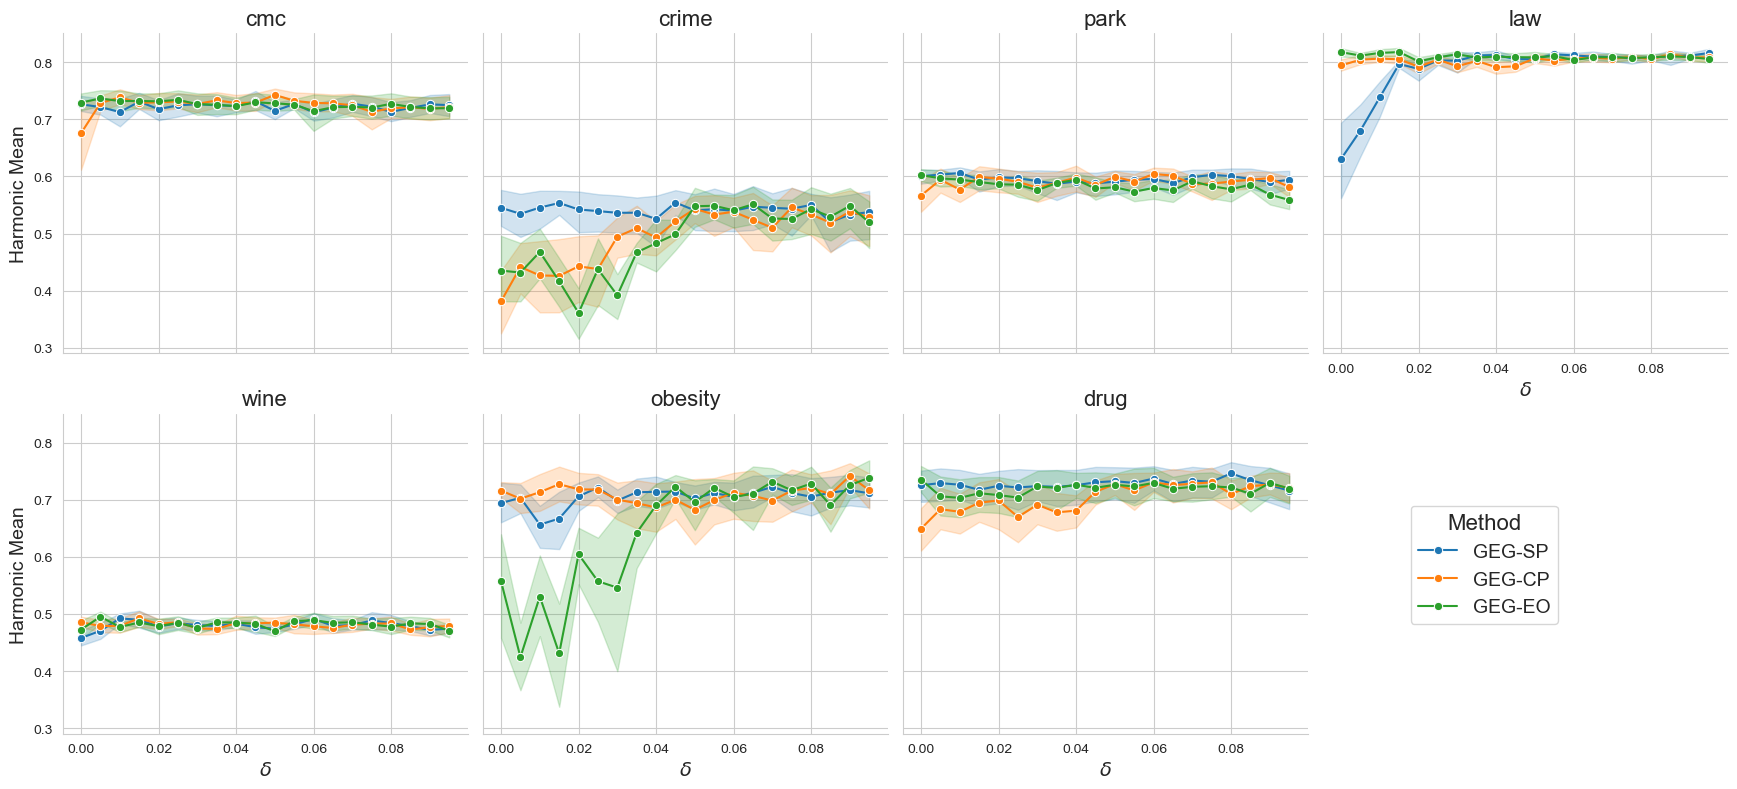

In [36]:
g = sns.FacetGrid(data, col="dataset", col_wrap=4, height=4)
g.map_dataframe(sns.lineplot, y="harmonic_mean", x="difference_bound", hue="constraint", marker="o")
g.set_axis_labels("$\\delta$", "Harmonic Mean", size=14)
g.set_titles(col_template="{col_name}", size=16)
g.add_legend(
    title="Constraint", loc="lower right", prop={"size": 14}, bbox_to_anchor=(0.9, 0.2),frameon=True)
# position the legend near the last plot
# sns.move_legend(g, "lower right", bbox_to_anchor=(0.9, 0.2))
g.legend.set_title("Method", prop={"size": 16})
plt.tight_layout()
plt.savefig("imgs/harmonic_mean_rq5.pdf", bbox_inches="tight")
plt.show()

## Eta sensitivity analysis

In [37]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import hmean

sns.set_style("whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

data_list = []
for filename in os.listdir("results_geg_rq5_eta"):
    if filename.endswith(".csv"):
        dataset = filename.split("_")[0]
        df = pd.read_csv(os.path.join("results_geg_rq5_eta", filename))
        df["dataset"] = dataset
        data_list.append(df)
data = pd.concat(data_list, ignore_index=True)

In [38]:
data = data.drop(columns=['statistical_parity', 'equal_opportunity', 'average_odds'])

In [39]:
data[["wc_statistical_parity", "wc_equal_opportunity", "wc_average_odds"]] = data[
    ["wc_statistical_parity", "wc_equal_opportunity", "wc_average_odds"]
].abs()

In [40]:
data['harmonic_mean'] = data.apply(
    lambda row: hmean([row['accuracy'], row['f1_score'], 1 - row['wc_statistical_parity'], 1 - row['wc_equal_opportunity'], 1 - row['wc_average_odds']]),
    axis=1)

In [41]:
data

,fold,accuracy,precision,recall,f1_score,wc_statistical_parity,wc_equal_opportunity,wc_average_odds,constraint,eta,dataset,harmonic_mean
0,1,0.6014,0.5915,0.5506,0.5343,0.0584,0.2500,0.0965,dp,1.0000,cmc,0.7106
1,2,0.5946,0.5833,0.5427,0.5156,0.0712,0.1508,0.0602,dp,1.0000,cmc,0.7205
2,3,0.5743,0.5305,0.5254,0.5230,0.0184,0.0351,0.0287,dp,1.0000,cmc,0.7421
3,4,0.6190,0.6485,0.5898,0.5794,0.0224,0.1088,0.0909,dp,1.0000,cmc,0.7592
4,5,0.6190,0.5737,0.5379,0.5392,0.1035,0.2206,0.1084,dp,1.0000,cmc,0.7153
...,...,...,...,...,...,...,...,...,...,...,...,...
3775,6,0.6649,0.6419,0.6206,0.6245,0.3011,0.1810,0.1485,eo,9.5000,drug,0.7213
3776,7,0.6968,0.5701,0.6055,0.5693,0.3072,0.4500,0.2864,eo,9.5000,drug,0.6366
3777,8,0.6915,0.6219,0.6024,0.6066,0.1715,0.2406,0.1445,eo,9.5000,drug,0.7367
3778,9,0.6596,0.6061,0.6152,0.6078,0.0509,0.1184,0.0642,eo,9.5000,drug,0.7791


In [42]:
data['constraint'] = data['constraint'].replace({
    'dp': 'GEG-SP',
    'eo': 'GEG-EO',
    'cp': 'GEG-CP',
})

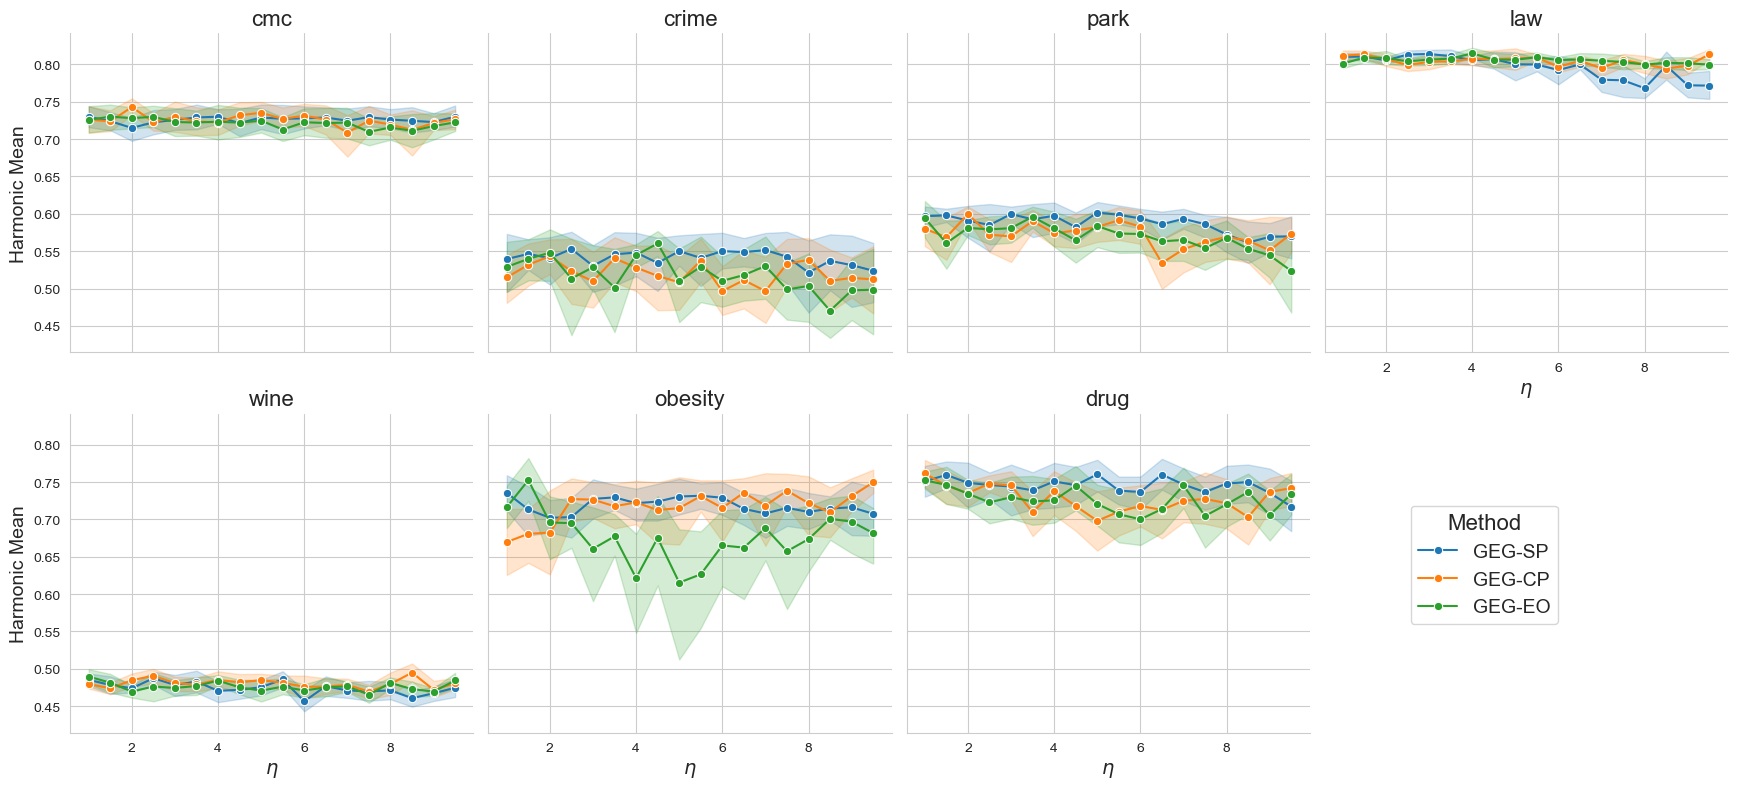

In [44]:
g = sns.FacetGrid(data, col="dataset", col_wrap=4, height=4)
g.map_dataframe(sns.lineplot, y="harmonic_mean", x="eta", hue="constraint", marker="o")
g.set_axis_labels("$\\eta$", "Harmonic Mean", size=14)
g.set_titles(col_template="{col_name}", size=16)
g.add_legend(
    title="Constraint", loc="lower right", prop={"size": 14}, bbox_to_anchor=(0.9, 0.2),frameon=True)
# position the legend near the last plot
# sns.move_legend(g, "lower right", bbox_to_anchor=(0.9, 0.2))
g.legend.set_title("Method", prop={"size": 16})
# plt.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
plt.tight_layout()
# plt.savefig("imgs/harmonic_mean_rq5_ratio_bound_slack.pdf", bbox_inches="tight")
plt.show()